@JeongHo_SEO - Final Models

### Description:
- Dataset: final_dataset_rate.csv
- 재무비율 및 기업 정보 관련 변수만 들어 있는, "전처리된" dataset. (NA 채우기 등.)
- Target: Bad (파산 or 부도),  bad event가 있었던 기업이라도 event가 일어나기 전 해에는 0으로 처리.
- Duration: 각각의 기업에 대해, 회계년 - 최초기록연도 (for 생존분석)

In [1]:
import pandas as pd
import numpy as np
import random
from sklearn.preprocessing import StandardScaler

from sklearn.utils import resample
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import TimeSeriesSplit

### 1. Dataset Preview & 추가 전처리

In [2]:
df = pd.read_csv('final_dataset_rate.csv')

print(df.shape)
print(df.head())

(96161, 24)
    Symbol  Name   결산월   회계년                상장폐지일자                     폐지사유  \
0  A000010  조흥은행  12.0  1999  2004-07-02T00:00:00Z  지주회사의 완전자회사화(지주회사 신규상장)   
1  A000010  조흥은행  12.0  2000  2004-07-02T00:00:00Z  지주회사의 완전자회사화(지주회사 신규상장)   
2  A000010  조흥은행  12.0  2001  2004-07-02T00:00:00Z  지주회사의 완전자회사화(지주회사 신규상장)   
3  A000010  조흥은행  12.0  2002  2004-07-02T00:00:00Z  지주회사의 완전자회사화(지주회사 신규상장)   
4  A000010  조흥은행  12.0  2003  2004-07-02T00:00:00Z  지주회사의 완전자회사화(지주회사 신규상장)   

   파산여부  부도여부  Bad  duration  ...  영업이익/총자본  유보이익/총자본    자기자본비율    자본금회전율  \
0     0     0    0         0  ... -0.417365 -0.469008  0.046722  1.062795   
1     0     0    0         1  ...  0.078942 -0.387289  0.041104  1.151435   
2     0     0    0         2  ...  0.310515 -0.133537  0.045285  1.060018   
3     0     0    0         3  ... -0.044457 -0.380895  0.034496  1.010100   
4     0     0    0         4  ... -0.348575 -0.945519  0.032365  0.972309   

   차입금의존도    총부채회전율   총자본투자효율    총자본회전율   총순자산수익률 

In [3]:
print(f"columns: {df.columns.to_list()}")
print(f"상장폐지 기업 개수: {df['Bad'].sum()}") # label 1 개수 (0, 1)

columns: ['Symbol', 'Name', '결산월', '회계년', '상장폐지일자', '폐지사유', '파산여부', '부도여부', 'Bad', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율']
상장폐지 기업 개수: 70


- Symbol: 기업 코드
- 회계년: 연도 (Time-Series)
- 상장폐지일자: 상장폐지 이후 data 모두 삭제 필요 [회생 등 무시]
- Bad: 0 or 1 == target feature label
- '금융비용/부채 - '현금성자산비율': input features

Quenstion. 상장폐지 이후 data 존재하는 기업?

In [4]:
# 1. Bad == 1을 가진 기업(Symbol) list
symbols_with_bad_1 = df[df['Bad'] == 1]['Symbol'].unique()

# 2. Bad == 1 이후에도 데이터가 있는 기업들?
symbols_with_post_bad_rows = []

# 3. Symbol별로 순회하며 체크
for symbol in symbols_with_bad_1:
    group = df[df['Symbol'] == symbol]  # 해당 Symbol의 모든 row
    bad_idx = group[group['Bad'] == 1].index

    if not bad_idx.empty:
        first_bad_idx = bad_idx[0]
        # Bad == 1 이후에도 행이 존재하는 경우
        if first_bad_idx < group.index.max():
            symbols_with_post_bad_rows.append(symbol)

# 4. 결과 확인
print("Bad == 1 이후에도 데이터가 있는 기업 목록:")
print(symbols_with_post_bad_rows)


Bad == 1 이후에도 데이터가 있는 기업 목록:
[]


- 상장폐지 이후 data 모두 삭제된 상태이므로, NA 체크

In [5]:
na_count = df.isna().sum()
na_ratio = df.isna().mean()

na_summary = pd.DataFrame({
    '결측값 개수': na_count,
    '결측값 비율': na_ratio
})

na_summary['결측값 비율'] = (na_summary['결측값 비율'] * 100).round(2).astype(str) + '%'

print(na_summary)

          결측값 개수  결측값 비율
Symbol         0    0.0%
Name           0    0.0%
결산월        29861  31.05%
회계년            0    0.0%
상장폐지일자     83319  86.65%
폐지사유       83521  86.86%
파산여부           0    0.0%
부도여부           0    0.0%
Bad            0    0.0%
duration       0    0.0%
금융비용/부채        0    0.0%
금융비용/총비용       0    0.0%
설비투자효율         0    0.0%
현금흐름/총자본       0    0.0%
영업이익/총자본       0    0.0%
유보이익/총자본       0    0.0%
자기자본비율         0    0.0%
자본금회전율         0    0.0%
차입금의존도         0    0.0%
총부채회전율         0    0.0%
총자본투자효율        0    0.0%
총자본회전율         0    0.0%
총순자산수익률        0    0.0%
현금성자산비율        0    0.0%


- 결산월의 경우 사용되는 feature가 아니라서 무시
- 폐지사유의 경우에도 이미 Bad를 target으로 정의할 때 사용했으니 무시
- 상장페지일자는 뭘까.... 체크
    - 1) 비상장폐지 기업의 경우 모든 연도 NA
    - 2) 상장폐지 기업의 경우 모든 연도에서 같은 일자

In [6]:
# 상장폐지한 기업
delisted_symbols = df[df['상장폐지일자'].notna()]['Symbol'].unique()

# 상장폐지 기업 수
n_delisted = len(delisted_symbols)

# 해당 기업들이 가진 row 수
n_delisted_rows = df[df['Symbol'].isin(delisted_symbols)].shape[0]


print(f"(1) 상장폐지 기업 수: {n_delisted}")
print(f"(1) 상장폐지 기업이 차지하는 row 수: {n_delisted_rows}\n")

#----------------------#

# Bad == 1인 기업
bad_1_symbols = df[df['Bad'] == 1]['Symbol'].unique()

# Bad == 1 기업 수
n_bad_1 = len(bad_1_symbols)

# 해당 기업들이 가진 row 수
n_bad_1_rows = df[df['Symbol'].isin(bad_1_symbols)].shape[0]

print(f"(2) Bad=1 기업 수: {n_bad_1}")
print(f"(2) Bad=1 기업이 차지하는 row 수: {n_bad_1_rows}\n")

#----------------------#

# 전체 기업 수
n_total_symbols = df['Symbol'].nunique()

# 전체 row 수
n_total_rows = df.shape[0]

print(f"(3) 전체 기업 수: {n_total_symbols}")
print(f"(3) 전체 row 수: {n_total_rows}\n")

#----------------------#

print(f"(4) 상장폐지 row 비율: {n_delisted_rows / n_total_rows:.2%}")

(1) 상장폐지 기업 수: 1342
(1) 상장폐지 기업이 차지하는 row 수: 12842

(2) Bad=1 기업 수: 70
(2) Bad=1 기업이 차지하는 row 수: 574

(3) 전체 기업 수: 5603
(3) 전체 row 수: 96161

(4) 상장폐지 row 비율: 13.35%


- (4)를 보니, 상장폐지일자에 있는 NA는 정당함!. 상장폐지했는데 NA로 기록된 사례는 없음.

#### Features 정제

- 상장폐지일자 -> 상장폐지년도로 변경.
- 회계년과 같은 연도단위로 사용하기 위함
- 안쓰는 feature 삭제
- ratio feature -> 표준화


In [7]:
# 상장폐지일자 -> 상장폐지년도로 변경.
df["상장폐지년도"] = pd.to_datetime(df["상장폐지일자"], errors="coerce").dt.year.astype("Int64")

drop_columns = ['Name', '결산월', '상장폐지일자', '폐지사유', '파산여부', '부도여부']
df = df.drop(columns=drop_columns)

print(f"columns: {df.columns.to_list()}")

columns: ['Symbol', '회계년', 'Bad', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율', '상장폐지년도']


In [8]:
columns = df.columns.to_list()

# columns 순서 이쁘게 정렬
columns = columns[:2] + [ columns[-1] ] + columns[3:-1] + [ columns[2] ]

print(f"columns: {columns}")
df = df[columns]

columns: ['Symbol', '회계년', '상장폐지년도', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율', 'Bad']


In [9]:
scaled_columns = columns[4:-1]
scaler = StandardScaler()
df_scaled_values = scaler.fit_transform(df[scaled_columns])

df_scaled = df.copy()
df_scaled[scaled_columns] = df_scaled_values

- 새로운 dataset file로 저장 (안하셔도 됩니다)
    - Columns Sorted
    - Columns Selected
    - Standardized Ratio Features

In [10]:
# csv로 저장
df.to_csv("managed.csv", index=False, encoding='utf-8-sig')

### 2. Non-Time Series Analysis
$\Rightarrow$ label의 경우 Bad event 이전은 모두 0으로 처리
- e.g. (Bad event 발생) Label = 0, 0, 0, ..., 1
- e.g. (Bad event 발생 X) Label = 0, 0, 0, ..., 0

#### Label Ratio (Case Sampling)

In [10]:
input_features = columns[:-1]
target_feature = columns[-1]

print(f"input features: {input_features}")
print(f"target feature: {target_feature}")

# label distribution
counts = df[target_feature].value_counts(normalize=False).sort_index()
ratios = df[target_feature].value_counts(normalize=True).sort_index()

for label in counts.index:
    count = counts[label]
    ratio = ratios[label]
    print(f'Label {label}: {count} 개 ({ratio:.2%})')


input features: ['Symbol', '회계년', '상장폐지년도', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율']
target feature: Bad
Label 0: 96091 개 (99.93%)
Label 1: 70 개 (0.07%)


In [11]:
print(df.head())

    Symbol   회계년  상장폐지년도  duration  금융비용/부채  금융비용/총비용    설비투자효율  현금흐름/총자본  \
0  A000010  1999    2004         0      0.0       0.0  2.493567  0.112994   
1  A000010  2000    2004         1      0.0       0.0  2.853872  0.720505   
2  A000010  2001    2004         2      0.0       0.0  2.668069  0.643380   
3  A000010  2002    2004         3      0.0       0.0  2.619010  0.704620   
4  A000010  2003    2004         4      0.0       0.0  2.715868  0.903742   

   영업이익/총자본  유보이익/총자본    자기자본비율    자본금회전율  차입금의존도    총부채회전율   총자본투자효율  \
0 -0.417365 -0.469008  0.046722  1.062795     0.0  0.080646 -0.019500   
1  0.078942 -0.387289  0.041104  1.151435     0.0  0.079727  0.003245   
2  0.310515 -0.133537  0.045285  1.060018     0.0  0.066594  0.014062   
3 -0.044457 -0.380895  0.034496  1.010100     0.0  0.052808 -0.001534   
4 -0.348575 -0.945519  0.032365  0.972309     0.0  0.059618 -0.011282   

     총자본회전율   총순자산수익률   현금성자산비율  Bad  
0  0.076878 -0.337671  0.025787    0  
1  0.076450  0.04626

#### Matched-Pairs Sampling 기법 사용 (1:k)
- Bad event 발생기업 1 : 비 발생기업 k matching
- Label 1 개수가 매우 적으므로, k = 5 사용

| Symbol | 회계년 | 상장폐지년도 | Bad |
|--------|--------|----------------|-----|
| A      | 2020   | 2020           | 1   |
| B      | 2020   | NaN            | 0   |
| C      | 2020   | NaN            | 0   |
| D      | 2020   | NaN            | 0   |
| E      | 2020   | NaN            | 0   |
| F      | 2020   | NaN            | 0   |


In [11]:
# 1. Bad = 1 기업 목록
bad_firms = df[df['Bad'] == 1]['Symbol'].unique()

# 2. Bad event 발생연도 정보 (Symbol, 회계년 = 상장폐지년도)
bad_events = df[df['Bad'] == 1][['Symbol', '상장폐지년도']].copy()

# 3. Bad 비발생 기업 Symbol 추출
symbol_bad_sum = df.groupby('Symbol')['Bad'].sum()
good_firms = symbol_bad_sum[symbol_bad_sum == 0].index

# 4. Bad 비발생 기업
df_good = df[df['Symbol'].isin(good_firms)].copy()

# 5. 매칭 시작
matched_neg_list = []

for _, row in bad_events.iterrows():
    fail_year = row['상장폐지년도']
    fail_symbol = row['Symbol']

    # 해당 연도에 존재하는 정상 기업 중 5개
    candidates = df_good[df_good['회계년'] == fail_year]

    if len(candidates) >= 5:
        matched = candidates.sample(n=5, replace=False, random_state=42)
        matched['matched_to'] = fail_symbol  # 어떤 Bad event 발생기업과 매칭됐는지 표시
        matched_neg_list.append(matched)

# 6. 최종 결합
df_neg_matched = pd.concat(matched_neg_list, ignore_index=True)
df_pos = df[df['Bad'] == 1].copy()
df_matched = pd.concat([df_pos, df_neg_matched], ignore_index=True)


In [13]:
print(df_pos.head())

        Symbol   회계년  상장폐지년도  duration   금융비용/부채  금융비용/총비용    설비투자효율  \
5812   A001150  2003    2003         4  0.301006  0.349108  7.353275   
6661   A001310  2012    2012        13  0.140968  0.086570  2.789950   
9868   A001890  2004    2004         5  0.117265  0.182017  1.437477   
10194  A001980  2002    2004         3  0.101917  0.119617  4.757537   
10726  A002130  2001    2001         2  0.069252  0.430069  0.385966   

        현금흐름/총자본  영업이익/총자본   유보이익/총자본    자기자본비율    자본금회전율    차입금의존도    총부채회전율  \
5812    0.507908  0.231577   1.437455 -2.806307  1.763127  1.450316  0.691477   
6661   -1.639224 -6.348441 -13.294435  0.113255  6.210845  0.049293  0.817553   
9868   13.084650  6.942818  44.648249 -0.011793  0.946780  0.415684  0.563331   
10194  -1.285327  1.950647 -15.500868  0.032272  1.603687  0.543411  0.917078   
10726   0.007613  0.096627   1.145621 -1.301494  1.270873  0.021866  0.106383   

        총자본투자효율    총자본회전율    총순자산수익률   현금성자산비율  Bad  
5812  -0.649876  2.631974 

In [14]:
print(df_neg_matched.head())

    Symbol   회계년  상장폐지년도  duration   금융비용/부채  금융비용/총비용     설비투자효율  현금흐름/총자본  \
0  A022520  2003    2012         3  0.013185  0.003096  87.433974 -0.168721   
1  A016140  2003    2012         4  0.055002  0.091426   0.367644  0.115701   
2  A025560  2003    <NA>         4  0.073620  0.040310   1.043897  0.002939   
3  A050120  2003    <NA>         3  0.012008  0.003868  16.838270 -0.133541   
4  A053210  2003    <NA>         2  0.049081  0.066368   1.317646 -1.127328   

   영업이익/총자본  유보이익/총자본    자기자본비율     자본금회전율    차입금의존도    총부채회전율   총자본투자효율  \
0  0.013005  0.239398  0.578152  12.224100  0.013676  4.276232  0.007519   
1  0.089248  0.309957  0.512842   5.194044  0.240555  0.695556  0.045770   
2 -0.031844  0.015885  0.762103   5.304692  0.121699  1.724317 -0.024268   
3  0.046711  0.447526  0.578132   8.480126  0.090747  3.168539  0.027005   
4 -1.217237 -2.193916  0.241514   0.395239  0.147209  0.351945 -0.293980   

     총자본회전율   총순자산수익률   현금성자산비율  Bad matched_to  
0  1.803919  0.010

In [15]:
print(df_matched.head())

    Symbol   회계년  상장폐지년도  duration   금융비용/부채  금융비용/총비용    설비투자효율   현금흐름/총자본  \
0  A001150  2003    2003         4  0.301006  0.349108  7.353275   0.507908   
1  A001310  2012    2012        13  0.140968  0.086570  2.789950  -1.639224   
2  A001890  2004    2004         5  0.117265  0.182017  1.437477  13.084650   
3  A001980  2002    2004         3  0.101917  0.119617  4.757537  -1.285327   
4  A002130  2001    2001         2  0.069252  0.430069  0.385966   0.007613   

   영업이익/총자본   유보이익/총자본    자기자본비율    자본금회전율    차입금의존도    총부채회전율   총자본투자효율  \
0  0.231577   1.437455 -2.806307  1.763127  1.450316  0.691477 -0.649876   
1 -6.348441 -13.294435  0.113255  6.210845  0.049293  0.817553 -0.718991   
2  6.942818  44.648249 -0.011793  0.946780  0.415684  0.563331 -0.081875   
3  1.950647 -15.500868  0.032272  1.603687  0.543411  0.917078  0.062951   
4  0.096627   1.145621 -1.301494  1.270873  0.021866  0.106383 -0.125760   

     총자본회전율    총순자산수익률   현금성자산비율  Bad matched_to  
0  2.631974   1.3

#### Correlation 기반 Feature Importance

           금융비용/부채  금융비용/총비용    설비투자효율  현금흐름/총자본  영업이익/총자본  유보이익/총자본  \
금융비용/부채   1.000000  0.647416 -0.040934  0.020968 -0.034984 -0.042043   
금융비용/총비용  0.647416  1.000000 -0.034229  0.006660 -0.010960 -0.045005   
설비투자효율   -0.040934 -0.034229  1.000000  0.005581 -0.003391  0.001986   
현금흐름/총자본  0.020968  0.006660  0.005581  1.000000 -0.627755 -0.243686   
영업이익/총자본 -0.034984 -0.010960 -0.003391 -0.627755  1.000000  0.771022   
유보이익/총자본 -0.042043 -0.045005  0.001986 -0.243686  0.771022  1.000000   
자기자본비율   -0.325486 -0.404689 -0.002225  0.027586 -0.061046 -0.039942   
자본금회전율   -0.167371 -0.273380  0.093653  0.025416  0.019937  0.050146   
차입금의존도    0.341638  0.348279 -0.040054 -0.025500  0.113832  0.084344   
총부채회전율   -0.179799 -0.390516  0.050980  0.057807 -0.013986  0.043041   
총자본투자효율  -0.420451 -0.278192  0.009930  0.125824 -0.000712  0.041222   
총자본회전율    0.066866 -0.243426  0.088295  0.038407  0.006395  0.075581   
총순자산수익률  -0.041450 -0.015228 -0.002342 -0.606725  0.977675  0.81

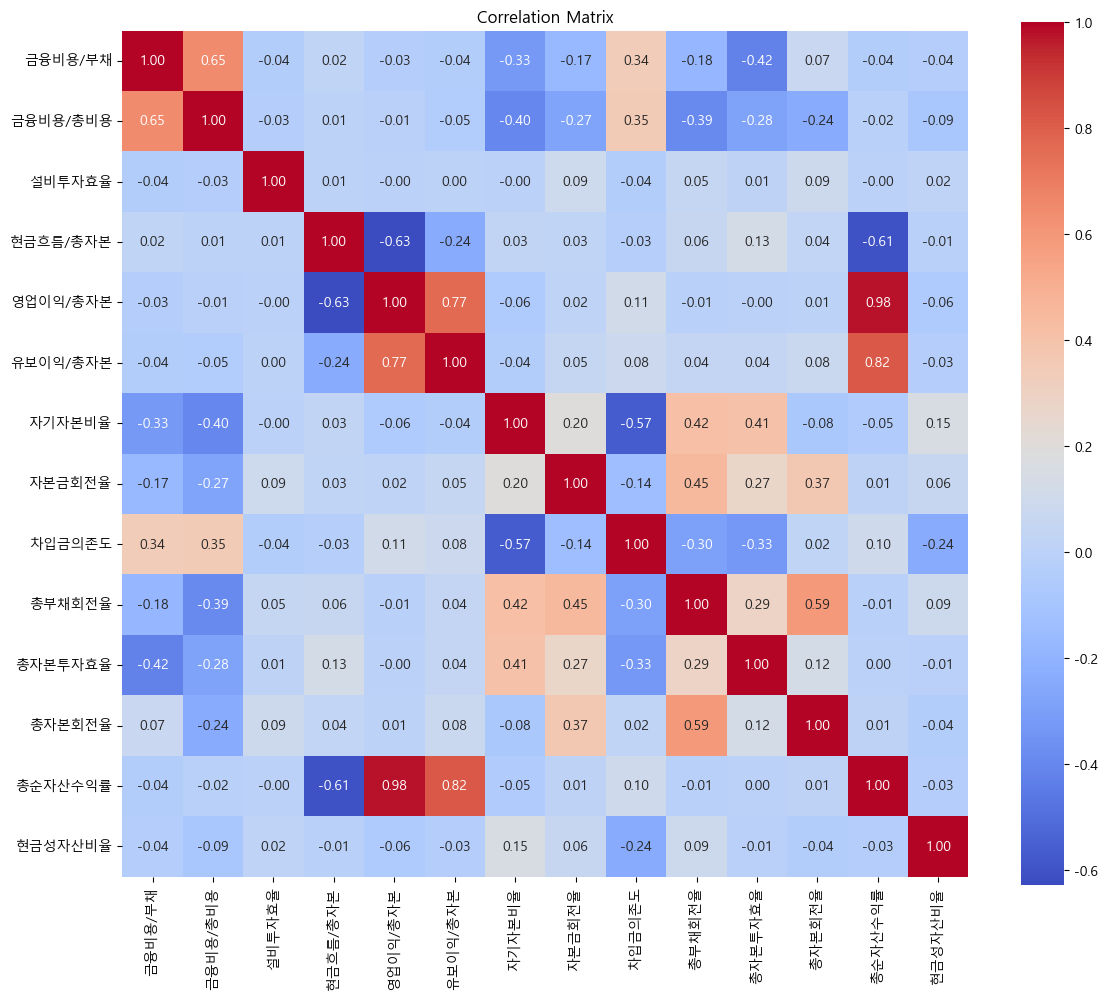

In [12]:
X = df_matched[input_features[4:]]
y = df_matched[target_feature]

correlation_matrix = X.corr()  # 기본값: Pearson correlation
print(correlation_matrix)

# font
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

- 다중공선성 기반 변수 소거
- Correlation 크기 > 0.8인 경우 소거

reduced input features list:
['총순자산수익률']

input features change:
(420, 14)
(420, 13)
_____________
           금융비용/부채  금융비용/총비용    설비투자효율  현금흐름/총자본  영업이익/총자본  유보이익/총자본  \
금융비용/부채   1.000000  0.647416 -0.040934  0.020968 -0.034984 -0.042043   
금융비용/총비용  0.647416  1.000000 -0.034229  0.006660 -0.010960 -0.045005   
설비투자효율   -0.040934 -0.034229  1.000000  0.005581 -0.003391  0.001986   
현금흐름/총자본  0.020968  0.006660  0.005581  1.000000 -0.627755 -0.243686   
영업이익/총자본 -0.034984 -0.010960 -0.003391 -0.627755  1.000000  0.771022   
유보이익/총자본 -0.042043 -0.045005  0.001986 -0.243686  0.771022  1.000000   
자기자본비율   -0.325486 -0.404689 -0.002225  0.027586 -0.061046 -0.039942   
자본금회전율   -0.167371 -0.273380  0.093653  0.025416  0.019937  0.050146   
차입금의존도    0.341638  0.348279 -0.040054 -0.025500  0.113832  0.084344   
총부채회전율   -0.179799 -0.390516  0.050980  0.057807 -0.013986  0.043041   
총자본투자효율  -0.420451 -0.278192  0.009930  0.125824 -0.000712  0.041222   
총자본회전율    0.066866 -0.243426  0.08829

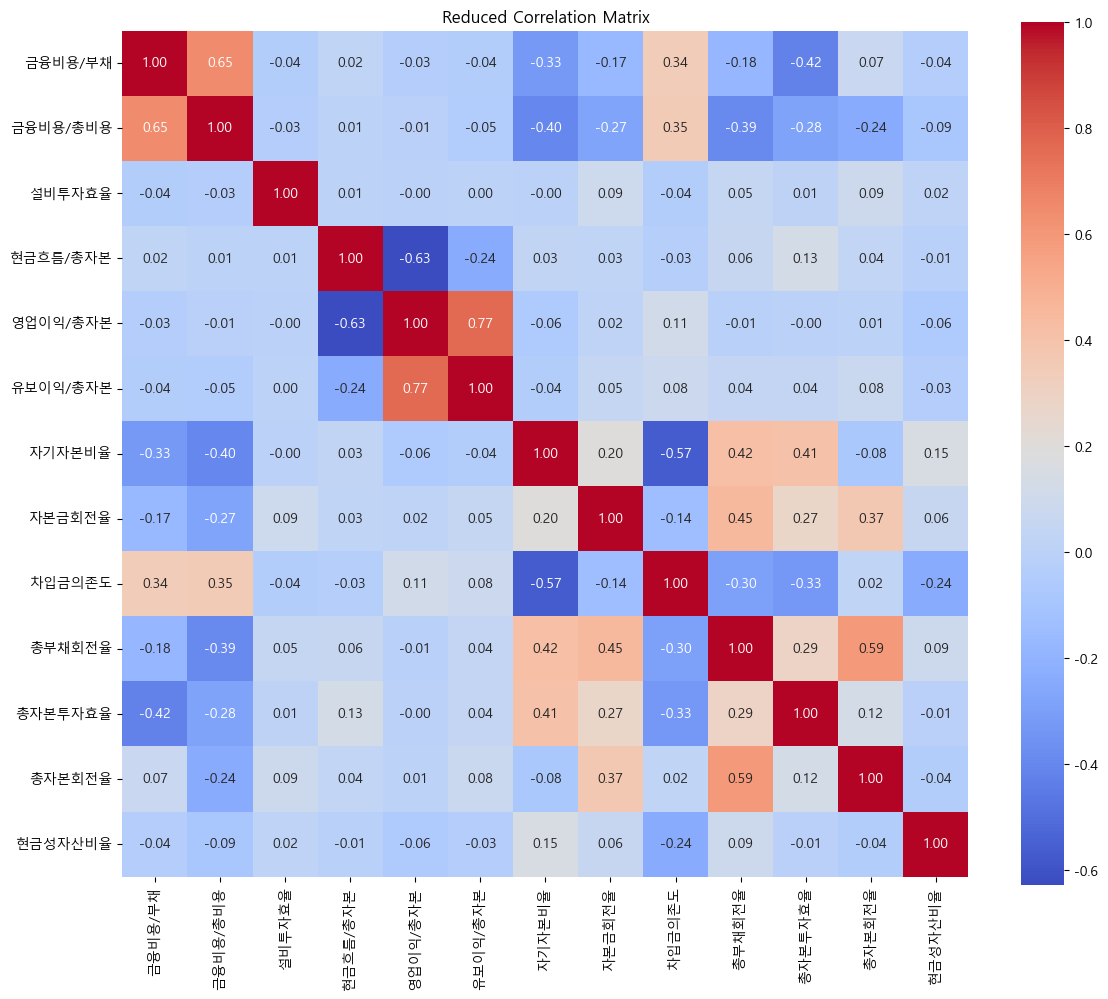

In [13]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]

print("reduced input features list:")
print(to_drop)

X_reduced = X.drop(columns=to_drop)

print("\ninput features change:")
print(X.shape)
print(X_reduced.shape)

print('_____________')
reduced_correlation_matrix = X_reduced.corr()
print(reduced_correlation_matrix)

# font
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# Heat map
plt.figure(figsize=(12, 10))
sns.heatmap(reduced_correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title("Reduced Correlation Matrix")
plt.tight_layout()
plt.show()

#### 5-folds & Modeling
Reduced input features (13개)로 5-folds cross validation
- Random Forest
- Adaboost
- MLP (Deep Learning)
- Ensemble (Voting)

- 기업별로 묶어서 random하게 기업이 7:3이 되도록 분할.
- X = df_matched[input_features[4:]]
- X_reduced
- y = df_matched[target_feature]

In [26]:
symbols = df_matched['Symbol'].values

# Symbol 기준 train/test 분할
unique_symbols = np.unique(symbols)
train_symbols, test_symbols = train_test_split(unique_symbols, test_size=0.3, random_state=42)

train_idx = df_matched['Symbol'].isin(train_symbols)
test_idx = df_matched['Symbol'].isin(test_symbols)

X_trainval = X_reduced[train_idx].reset_index(drop=True)
y_trainval = y[train_idx].reset_index(drop=True)
X_test = X_reduced[test_idx].reset_index(drop=True)
y_test = y[test_idx].reset_index(drop=True)

# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

Cross Validation

In [27]:
best_models = {}

for model_name, model_template in models.items():
    print(f"\n🔍 모델: {model_name}")
    fold_scores = []

    best_model = None
    best_auc = -1
    best_fold = -1

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx_fold, val_idx_fold) in enumerate(skf.split(X_trainval, y_trainval)):
        X_train = X_trainval.iloc[train_idx_fold]
        y_train = y_trainval.iloc[train_idx_fold]
        X_val = X_trainval.iloc[val_idx_fold]
        y_val = y_trainval.iloc[val_idx_fold]

        model = model_template.__class__(**model_template.get_params())
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fold_scores.append((fold + 1, acc, auc))

        print(f"Fold {fold + 1}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

        if acc > 0.8 and auc > best_auc:
            best_model = model
            best_auc = auc
            best_fold = fold + 1

    if best_model is not None:
        best_models[model_name] = best_model
        print(f"선택된 Best Fold: Fold {best_fold} (AUC = {best_auc:.4f})\n")
    else:
        print(f"❌ 조건을 만족하는 fold 없음 (accuracy > 0.8)")


🔍 모델: RandomForest
Fold 1: Accuracy = 0.8966, AUC = 0.9845
Fold 2: Accuracy = 0.9310, AUC = 0.9906
Fold 3: Accuracy = 0.9310, AUC = 0.9854
Fold 4: Accuracy = 0.8966, AUC = 0.9094
Fold 5: Accuracy = 0.9649, AUC = 0.9851
선택된 Best Fold: Fold 2 (AUC = 0.9906)


🔍 모델: AdaBoost
Fold 1: Accuracy = 0.9310, AUC = 0.9420
Fold 2: Accuracy = 0.9310, AUC = 0.9896
Fold 3: Accuracy = 0.9310, AUC = 0.9813
Fold 4: Accuracy = 0.8966, AUC = 0.7354
Fold 5: Accuracy = 0.8947, AUC = 0.9606
선택된 Best Fold: Fold 2 (AUC = 0.9896)


🔍 모델: MLP
Fold 1: Accuracy = 0.8621, AUC = 0.9207
Fold 2: Accuracy = 0.8448, AUC = 0.8812
Fold 3: Accuracy = 0.8966, AUC = 0.8917
Fold 4: Accuracy = 0.9310, AUC = 0.8771
Fold 5: Accuracy = 0.9123, AUC = 0.8319
선택된 Best Fold: Fold 1 (AUC = 0.9207)



c:\Users\HOME\Desktop\VSC\2025_spring_Data_Mining\DM_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Test

In [28]:
test_results = {}
voting_proba_list = []

for model_name, model in best_models.items():
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba)

    voting_proba_list.append(y_test_proba)

    test_results[model_name] = {
        'accuracy': acc,
        'roc_auc': auc
    }

# Soft Voting Ensemble (3개 모델 전부 있는 경우만)
if len(voting_proba_list) == 3:
    avg_proba = np.mean(voting_proba_list, axis=0)
    y_voting = (avg_proba >= 0.5).astype(int)

    acc_voting = accuracy_score(y_test, y_voting)
    auc_voting = roc_auc_score(y_test, avg_proba)

    test_results['VotingEnsemble'] = {
        'accuracy': acc_voting,
        'roc_auc': auc_voting
    }

# 결과 출력
for model_name, result in test_results.items():
    print(f"{model_name:15s} | Accuracy: {result['accuracy']:.4f} | ROC AUC: {result['roc_auc']:.4f}")


RandomForest    | Accuracy: 0.9160 | ROC AUC: 0.9337
AdaBoost        | Accuracy: 0.9237 | ROC AUC: 0.8703
MLP             | Accuracy: 0.9008 | ROC AUC: 0.8473
VotingEnsemble  | Accuracy: 0.9008 | ROC AUC: 0.9460


#### Random Forest 기반 Feature Importance

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20236\1170696816.py:20: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\HOME\Desktop\VSC\2025_spring_Data_Mining\DM_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


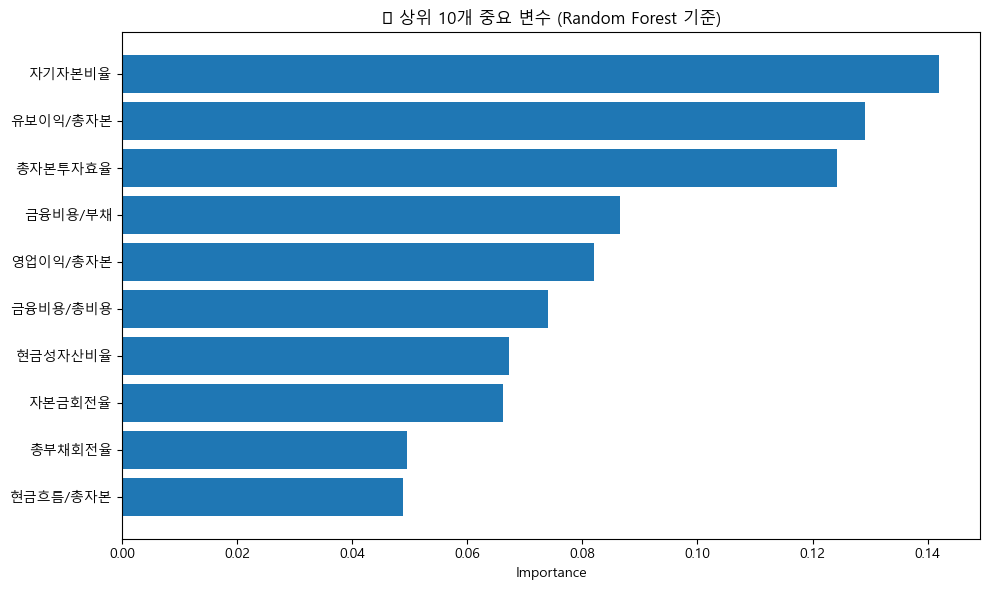

In [29]:
# 1. RandomForest 학습 (전체 데이터 사용)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_reduced, y)

# 2. 중요도 추출
importances = rf.feature_importances_
feature_names = X_reduced.columns

# 3. 중요도 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. 상위 중요 변수 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.title("📌 상위 10개 중요 변수 (Random Forest 기준)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

#### Reduced Features 대신, 전체 Features로 modeling
- '총순자산수익률' 포함 14개

In [33]:
symbols = df_matched['Symbol'].values

# Symbol 기준 train/test 분할
unique_symbols = np.unique(symbols)
train_symbols, test_symbols = train_test_split(unique_symbols, test_size=0.3, random_state=42)

train_idx = df_matched['Symbol'].isin(train_symbols)
test_idx = df_matched['Symbol'].isin(test_symbols)

X_trainval = X[train_idx].reset_index(drop=True)
y_trainval = y[train_idx].reset_index(drop=True)
X_test = X[test_idx].reset_index(drop=True)
y_test = y[test_idx].reset_index(drop=True)

# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

Cross Validation

In [34]:
best_models = {}

for model_name, model_template in models.items():
    print(f"\n🔍 모델: {model_name}")
    fold_scores = []

    best_model = None
    best_auc = -1
    best_fold = -1

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for fold, (train_idx_fold, val_idx_fold) in enumerate(skf.split(X_trainval, y_trainval)):
        X_train = X_trainval.iloc[train_idx_fold]
        y_train = y_trainval.iloc[train_idx_fold]
        X_val = X_trainval.iloc[val_idx_fold]
        y_val = y_trainval.iloc[val_idx_fold]

        model = model_template.__class__(**model_template.get_params())
        model.fit(X_train, y_train)

        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]

        acc = accuracy_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_proba)
        fold_scores.append((fold + 1, acc, auc))

        print(f"Fold {fold + 1}: Accuracy = {acc:.4f}, AUC = {auc:.4f}")

        if acc > 0.8 and auc > best_auc:
            best_model = model
            best_auc = auc
            best_fold = fold + 1

    if best_model is not None:
        best_models[model_name] = best_model
        print(f"선택된 Best Fold: Fold {best_fold} (AUC = {best_auc:.4f})\n")
    else:
        print(f"❌ 조건을 만족하는 fold 없음 (accuracy > 0.8)")


🔍 모델: RandomForest
Fold 1: Accuracy = 0.9138, AUC = 0.9884
Fold 2: Accuracy = 0.9310, AUC = 0.9740
Fold 3: Accuracy = 0.9483, AUC = 0.9833
Fold 4: Accuracy = 0.8966, AUC = 0.9531
Fold 5: Accuracy = 0.9649, AUC = 0.9851
선택된 Best Fold: Fold 1 (AUC = 0.9884)


🔍 모델: AdaBoost
Fold 1: Accuracy = 0.9310, AUC = 0.9749
Fold 2: Accuracy = 0.9483, AUC = 0.9979
Fold 3: Accuracy = 0.9138, AUC = 0.9354
Fold 4: Accuracy = 0.8966, AUC = 0.7635
Fold 5: Accuracy = 0.9123, AUC = 0.9511
선택된 Best Fold: Fold 2 (AUC = 0.9979)


🔍 모델: MLP
Fold 1: Accuracy = 0.8621, AUC = 0.9130
Fold 2: Accuracy = 0.9138, AUC = 0.9083
Fold 3: Accuracy = 0.9138, AUC = 0.9396
Fold 4: Accuracy = 0.9310, AUC = 0.8104
Fold 5: Accuracy = 0.9123, AUC = 0.9340
선택된 Best Fold: Fold 3 (AUC = 0.9396)



Test

In [35]:
test_results = {}
voting_proba_list = []

for model_name, model in best_models.items():
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_test_pred)
    auc = roc_auc_score(y_test, y_test_proba)

    voting_proba_list.append(y_test_proba)

    test_results[model_name] = {
        'accuracy': acc,
        'roc_auc': auc
    }

# Soft Voting Ensemble (3개 모델 전부 있는 경우만)
if len(voting_proba_list) == 3:
    avg_proba = np.mean(voting_proba_list, axis=0)
    y_voting = (avg_proba >= 0.5).astype(int)

    acc_voting = accuracy_score(y_test, y_voting)
    auc_voting = roc_auc_score(y_test, avg_proba)

    test_results['VotingEnsemble'] = {
        'accuracy': acc_voting,
        'roc_auc': auc_voting
    }

# 결과 출력
for model_name, result in test_results.items():
    print(f"{model_name:15s} | Accuracy: {result['accuracy']:.4f} | ROC AUC: {result['roc_auc']:.4f}")


RandomForest    | Accuracy: 0.9008 | ROC AUC: 0.9098
AdaBoost        | Accuracy: 0.8855 | ROC AUC: 0.8332
MLP             | Accuracy: 0.8931 | ROC AUC: 0.8665
VotingEnsemble  | Accuracy: 0.8931 | ROC AUC: 0.9225


#### Random Forest 기반 Feature Importance

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_20236\3014796290.py:20: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\HOME\Desktop\VSC\2025_spring_Data_Mining\DM_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


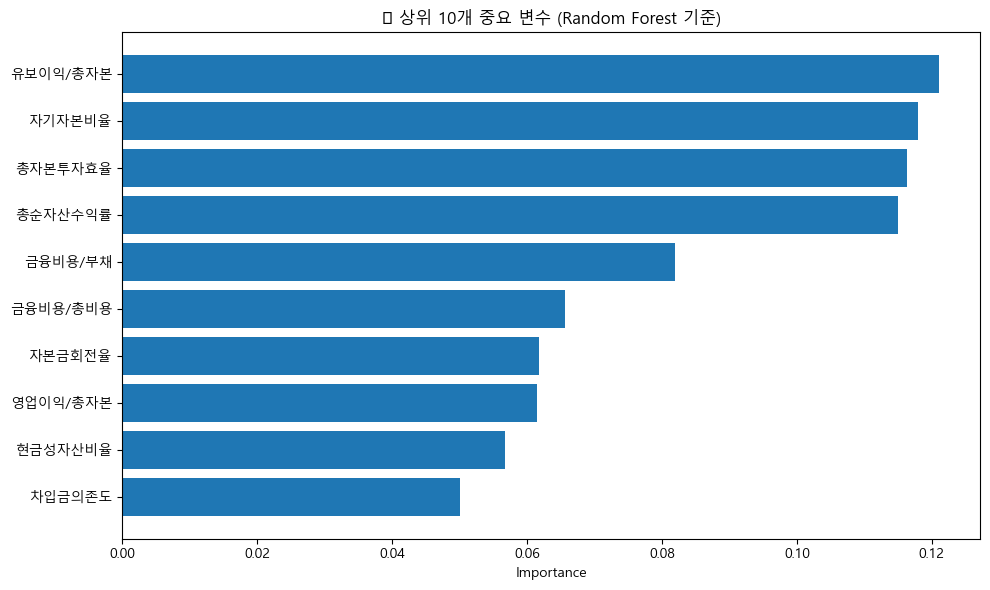

In [37]:
# 1. RandomForest 학습 (전체 데이터 사용)
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)

# 2. 중요도 추출
importances = rf.feature_importances_
feature_names = X.columns

# 3. 중요도 정리
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 4. 상위 중요 변수 시각화
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1])
plt.title("📌 상위 10개 중요 변수 (Random Forest 기준)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

- Reduced Features의 Feature Importance에 비해 Feature Importance가 일부 순서가 변동되었으나, 크게 달라지지는 않았습니다.

#### 성능 비교
- Reduced Features vs 전체 Features

In [39]:
# 모델 정의
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
}

# 평가할 feature set
X_variants = {
    'AllFeatures': X,
    'ReducedFeatures': X_reduced
}

# Symbol 기반 train/test 분할
symbols = df_matched['Symbol'].values
unique_symbols = np.unique(symbols)
train_symbols, test_symbols = train_test_split(unique_symbols, test_size=0.3, random_state=42)

# 결과 저장
results = {}

# 각 feature set 별로 test 평가
for variant_name, X_variant in X_variants.items():
    print(f"\n======== 🌟 {variant_name} 🌟 ========")

    X_trainval = X_variant[df_matched['Symbol'].isin(train_symbols)].reset_index(drop=True)
    y_trainval = y[df_matched['Symbol'].isin(train_symbols)].reset_index(drop=True)
    X_test = X_variant[df_matched['Symbol'].isin(test_symbols)].reset_index(drop=True)
    y_test = y[df_matched['Symbol'].isin(test_symbols)].reset_index(drop=True)

    best_models = {}
    for model_name, model_template in models.items():
        best_model = None
        best_auc = -1
        best_fold = -1

        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_trainval, y_trainval)):
            X_train = X_trainval.iloc[train_idx]
            y_train = y_trainval.iloc[train_idx]
            X_val = X_trainval.iloc[val_idx]
            y_val = y_trainval.iloc[val_idx]

            model = model_template.__class__(**model_template.get_params())
            model.fit(X_train, y_train)

            y_pred = model.predict(X_val)
            y_proba = model.predict_proba(X_val)[:, 1]
            acc = accuracy_score(y_val, y_pred)
            auc = roc_auc_score(y_val, y_proba)

            if acc > 0.8 and auc > best_auc:
                best_model = model
                best_auc = auc
                best_fold = fold + 1

        if best_model is not None:
            best_models[model_name] = best_model
        else:
            print(f"❌ {variant_name} - {model_name}: No valid fold")

    # test 평가
    test_result = {}
    proba_list = []

    for model_name, model in best_models.items():
        y_test_pred = model.predict(X_test)
        y_test_proba = model.predict_proba(X_test)[:, 1]

        acc = accuracy_score(y_test, y_test_pred)
        auc = roc_auc_score(y_test, y_test_proba)

        test_result[model_name] = {
            'Accuracy': round(acc, 4),
            'ROC_AUC': round(auc, 4)
        }

        proba_list.append(y_test_proba)

    # Soft Voting Ensemble
    if len(proba_list) == 3:
        avg_proba = np.mean(proba_list, axis=0)
        y_vote = (avg_proba >= 0.5).astype(int)
        acc_vote = accuracy_score(y_test, y_vote)
        auc_vote = roc_auc_score(y_test, avg_proba)

        test_result['VotingEnsemble'] = {
            'Accuracy': round(acc_vote, 4),
            'ROC_AUC': round(auc_vote, 4)
        }

    results[variant_name] = pd.DataFrame(test_result).T

# 결과 비교 출력
print("\n🎯 Test 성능 비교 요약:")
comparison = pd.concat(results, axis=1)
print(comparison)


======== 🌟 AllFeatures 🌟 ========

======== 🌟 ReducedFeatures 🌟 ========

🎯 Test 성능 비교 요약:
               AllFeatures         ReducedFeatures        
                  Accuracy ROC_AUC        Accuracy ROC_AUC
RandomForest        0.9008  0.9098          0.9160  0.9337
AdaBoost            0.8855  0.8332          0.9237  0.8703
MLP                 0.8931  0.8665          0.9008  0.8473
VotingEnsemble      0.8931  0.9225          0.9008  0.9460


c:\Users\HOME\Desktop\VSC\2025_spring_Data_Mining\DM_env\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


- 성능이 모두 훌륭하네요. 전반적으로는 '총순자산수익률'의 포함 여부가 성능에 영향을 미치지 않는 것 같습니다. 뺴는 게 더 simple model이 될 것 같아요.
- ** pre_modeling_ver1.ipynb ** 에 비해 성능이 매우 개선되었습니다. (Below: 변화된 점)
  - 1) 상장폐지 이후 data 삭제
  - 2) 전처리 정제
  - 3) matched-pairs sampling 기법 도입. (이전: Simple case sampling)

### 3. Time Series Analysis
$\Rightarrow$ label의 경우 sliding window 방식으로 처리.
- window size = k
- N-k, ..., N-1 recent k개 년도 data $\rightarrow$ N 년도 bad = 1 여부.
- each sample = (N-k, ..., N-1 recent k개 년도 input feature & N 년도 label)
- dataset = all samples, 기업별 구분 무시 (k개 년도에 따른 label값만 중요)

- k개 년도 연속 sliding window 생성
    - 불연속 window 제거: 연도가 연속적이지 않은 경우에는 해당 sample 제거. (ex. 2000, **2001, 2003**, 2004, 2005)
    - each sample마다 y-label 부여.

- "https://gmnam.tistory.com/230"에 나오는 TimeSeriesSplit 방식 사용.
    - Time Series data의 5folds 방식, 시간의 연속성 때문

- k개 년도 sliding window 생성

In [31]:
print(f"df's columns: {columns}")
print(f"input features: {input_features}")
print(f"target feature: {target_feature}")

df's columns: ['Symbol', '회계년', '상장폐지년도', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율', 'Bad']
input features: ['Symbol', '회계년', '상장폐지년도', 'duration', '금융비용/부채', '금융비용/총비용', '설비투자효율', '현금흐름/총자본', '영업이익/총자본', '유보이익/총자본', '자기자본비율', '자본금회전율', '차입금의존도', '총부채회전율', '총자본투자효율', '총자본회전율', '총순자산수익률', '현금성자산비율']
target feature: Bad


In [40]:
selected_features = [ input_features[1] ] + input_features[4:-1]

def generate_sliding_windows(df, k):
    samples = []
    grouped = df.groupby('Symbol')

    for symbol, group in grouped:
        group = group.sort_values('회계년').reset_index(drop=True)
        years = group['회계년'].values
        features = group[selected_features].values

        for i in range(len(group) - k):
            window_years = years[i:i + k + 1]
            if not np.all(np.diff(window_years) == 1):  # 연속 연도 아닌 경우 제거
                continue

            X_window = features[i:i + k] # k개 년도의 연속된 feature
            prediction_year = years[i + k] # 예측할 연도
            y_label = group.loc[i + k, 'Bad'] # 예측할 연도의 label

            samples.append((X_window, y_label, prediction_year))

    return samples

In [41]:
k = 3 # tuning parameter, k=5는 data가 너무 적어서
samples = generate_sliding_windows(df, k) # X_window, y_label, prediction_year

# prediction_year 기준으로 정렬
samples.sort(key=lambda x: x[2])

#### Label Distribution (Case Sampling)

In [43]:
def check_label_distribution(dataset, name="Dataset"):
    # (X, y) 또는 (X, y, year) 모두 처리 가능
    labels = [y for item in dataset for i, y in enumerate(item) if i == 1]
    unique, counts = np.unique(labels, return_counts=True)

    print(f"\n{name} 샘플 수: {len(labels)}")
    for u, c in zip(unique, counts):
        print(f"- Label {u}: {c}개 ({c / len(labels):.2%})")


check_label_distribution(samples)


Dataset 샘플 수: 79390
- Label 0: 79332개 (99.93%)
- Label 1: 58개 (0.07%)


- 위에서 time sequence로 분석하기 전 Label 1: 70개 였는데, 그 중 12개가 사라졌습니다. 아무래도 연속되지 않은 연도가 12개가 있었던 것 같아요
- 이전에 제가 한 NA처리 방식과 다르게 NA가 처리되니, 더 적은 sample이 살아남았습니다.
- 이전에는 (fin_modeling_ver2.ipynb) 8069 중 6718, 1351개 살아남았어요

- sample: X_window, y_label, prediction_year

In [91]:
print(f"1st sample example: \n{samples[0]}\n")

print(f"1st sample input: {samples[0][0]}")
print(f"1st sample label: {samples[0][1]}")
if samples[0][1] == 1:
    print(f"1st sample 상장폐지년도: {samples[0][2]}")
else:
    print(f"1st sample: 상장폐지 X")
print(f"1st sample 입력연도: {samples[0][2]-k}-{samples[0][2]-(k-2)}")
print(f"1st sample 예측연도: {samples[0][2]}")


print([s[2] for s in samples[:10]])  # 처음 10개 예측 연도 출력

1st sample example: 
(array([[ 1.99900000e+03,  0.00000000e+00,  0.00000000e+00,
         2.49356708e+00,  1.12994237e-01, -4.17364802e-01,
        -4.69007612e-01,  4.67222215e-02,  1.06279454e+00,
         0.00000000e+00,  8.06462340e-02, -1.95002108e-02,
         7.68782628e-02, -3.37670871e-01],
       [ 2.00000000e+03,  0.00000000e+00,  0.00000000e+00,
         2.85387228e+00,  7.20504946e-01,  7.89422480e-02,
        -3.87288803e-01,  4.11040056e-02,  1.15143469e+00,
         0.00000000e+00,  7.97274734e-02,  3.24484260e-03,
         7.64503549e-02,  4.62677301e-02],
       [ 2.00100000e+03,  0.00000000e+00,  0.00000000e+00,
         2.66806945e+00,  6.43380103e-01,  3.10514607e-01,
        -1.33537372e-01,  4.52846104e-02,  1.06001783e+00,
         0.00000000e+00,  6.65939849e-02,  1.40615330e-02,
         6.35783022e-02,  2.05989545e-01]]), np.int64(0), np.int64(2002))

1st sample input: [[ 1.99900000e+03  0.00000000e+00  0.00000000e+00  2.49356708e+00
   1.12994237e-01 -4.1736

- 배열로 변환: TimeSeriesSplit (Time-Sequence)
- Test set 분리: 2017~2024년
- Modeling Set: 1999+ k ~ 2016년

In [76]:
X_window = np.array([s[0] for s in samples])
y_label = np.array([s[1] for s in samples])
prediction_year = np.array([s[2] for s in samples])


test_mask = (prediction_year >= 2017)
prediction_year_modeling = prediction_year[~test_mask]

X_test = X_window[test_mask]
y_test = y_label[test_mask]

X_modeling = X_window[~test_mask]
y_modeling = y_label[~test_mask]

#### Case sampling: y label ratio 1:1
- TimeSeriesSplit 도중 loss function에 weight를 부여해서 불균형을 해소할 예정입니다.

In [52]:
def check_label_distribution_from_array(y, name=""):
    y = np.array(y)
    total = len(y)
    num_1 = np.sum(y == 1)
    num_0 = np.sum(y == 0)
    print(f"[{name}] Total: {total}, 1 비율: {num_1/total:.4f}, 1 개수: {num_1}, 0 개수: {num_0}")


check_label_distribution_from_array(y_modeling, "Modeling Set")
check_label_distribution_from_array(y_test, "Test Set")

[Modeling Set] Total: 50875, 1 비율: 0.0009, 1 개수: 48, 0 개수: 50827
[Test Set] Total: 28515, 1 비율: 0.0004, 1 개수: 10, 0 개수: 28505


#### Modeling
- Accuracy와 함께 AUC curve를 사용. (Un-balanced ratio data)
- Test Set: Acuracy > 0.8 & AUC가 가장 큰 fold의 model 선택

- Seed: 고정, 결과 재현성 확보

In [56]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # CuDNN 관련 추가 옵션 (완전한 재현성)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [59]:
set_seed(42)

- MLP

In [60]:
class MLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc = nn.Sequential(
        nn.Flatten(),
        nn.Linear(input_size, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 1)
        )


    def forward(self, x):
        return self.fc(x)

# hyperparameters
n_splits = 5
batch_size = 64
lr = 1e-3
num_epochs = 20


input_size = X_modeling.shape[1] * X_modeling.shape[2]

Cross Validation

In [77]:
MLP_best_fold_info = {
    "fold": None,
    "acc": 0,
    "auc": 0,
    "model": None
}
MLP_acc_list = []
MLP_auc_list = []

tscv = TimeSeriesSplit(n_splits=n_splits)

print("==== TimeSeriesSplit MLP Training with Weighted Loss ====")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modeling)):
    # 데이터 선택
    X_train = torch.tensor(X_modeling[train_idx], dtype=torch.float32)
    y_train = torch.tensor(y_modeling[train_idx], dtype=torch.float32)
    X_val = torch.tensor(X_modeling[val_idx], dtype=torch.float32)
    y_val = torch.tensor(y_modeling[val_idx], dtype=torch.float32)

    # 연도 출력
    train_years = prediction_year_modeling[train_idx]
    val_years = prediction_year_modeling[val_idx]
    print(f"[Fold {fold+1}] 예측 연도 범위 (Train): {train_years.min()} ~ {train_years.max()}, (Val): {val_years.min()} ~ {val_years.max()}")

    # 불균형 보정
    num_pos = (y_train == 1).sum().item()
    num_neg = (y_train == 0).sum().item()
    pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

    # 모델 정의
    model = MLP(input_size)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)

    # 학습
    for epoch in range(num_epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb).squeeze()
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

    # 검증
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val).squeeze()
        val_probs = torch.sigmoid(val_logits).numpy()
        val_pred = (val_probs >= 0.5).astype(int)

        acc = accuracy_score(y_val.numpy(), val_pred)
        auc = roc_auc_score(y_val.numpy(), val_probs)

        MLP_acc_list.append(acc)
        MLP_auc_list.append(auc)

        print(f"[Fold {fold+1}] Validation Accuracy: {acc:.4f}, ROC AUC: {auc:.4f}\n")

        if acc > 0.8 and auc > MLP_best_fold_info["auc"]:
            MLP_best_fold_info.update({
                "fold": fold + 1,
                "acc": acc,
                "auc": auc,
                "model": model
            })

==== TimeSeriesSplit MLP Training with Weighted Loss ====
[Fold 1] 예측 연도 범위 (Train): 2002 ~ 2004, (Val): 2004 ~ 2007
[Fold 1] Validation Accuracy: 0.9993, ROC AUC: 0.3759

[Fold 2] 예측 연도 범위 (Train): 2002 ~ 2007, (Val): 2007 ~ 2009
[Fold 2] Validation Accuracy: 0.9912, ROC AUC: 0.9263

[Fold 3] 예측 연도 범위 (Train): 2002 ~ 2009, (Val): 2009 ~ 2012
[Fold 3] Validation Accuracy: 0.9700, ROC AUC: 0.7379

[Fold 4] 예측 연도 범위 (Train): 2002 ~ 2012, (Val): 2012 ~ 2014
[Fold 4] Validation Accuracy: 0.9995, ROC AUC: 0.5099

[Fold 5] 예측 연도 범위 (Train): 2002 ~ 2014, (Val): 2014 ~ 2016
[Fold 5] Validation Accuracy: 0.9968, ROC AUC: 0.5660



Test

In [ ]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("==== Test Evaluation ====")
if MLP_best_fold_info["model"] is not None:
    best_model = MLP_best_fold_info["model"]
    best_model.eval()
    with torch.no_grad():
        test_logits = best_model(X_test_tensor).squeeze()
        test_probs = torch.sigmoid(test_logits).numpy()
        test_pred = (test_probs >= 0.5).astype(int)

        test_acc = accuracy_score(y_test_tensor.numpy(), test_pred)
        test_auc = roc_auc_score(y_test_tensor.numpy(), test_probs)

        print(f"[Selected Fold {MLP_best_fold_info['fold']}] Test Accuracy: {test_acc:.4f}, ROC AUC: {test_auc:.4f}")
else:
    print("No fold satisfied the accuracy > 0.8 condition.")

==== Test Evaluation ====
[Selected Fold 2] Test Accuracy: 0.9991, ROC AUC: 0.6820


- GRU

In [80]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1, bidirectional=False):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional
        )
        self.fc = nn.Linear(hidden_size * (2 if bidirectional else 1), 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.gru(x)
        # 마지막 타임스텝의 출력만 사용
        out = out[:, -1, :]  # shape: (batch, hidden_size)
        return self.fc(out)  # logits (no sigmoid)


# hyperparameters
n_splits = 5
batch_size = 64
lr = 1e-3
num_epochs = 20

input_dim = X_modeling.shape[2]  # 시계열 feature 수

Cross Validation

In [81]:
GRU_best_fold_info = {
    "fold": None,
    "acc": 0,
    "auc": 0,
    "model": None
}

GRU_acc_list = []
GRU_auc_list = []

tscv = TimeSeriesSplit(n_splits=n_splits)

print("==== TimeSeriesSplit GRU Training with Weighted Loss ====")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modeling)):
    X_train = torch.tensor(X_modeling[train_idx], dtype=torch.float32)
    y_train = torch.tensor(y_modeling[train_idx], dtype=torch.float32)
    X_val = torch.tensor(X_modeling[val_idx], dtype=torch.float32)
    y_val = torch.tensor(y_modeling[val_idx], dtype=torch.float32)

    train_years = prediction_year_modeling[train_idx]
    val_years = prediction_year_modeling[val_idx]
    print(f"[Fold {fold+1}] 입력 연도 범위 (Train): {train_years.min()} ~ {train_years.max()}, (Val): {val_years.min()} ~ {val_years.max()}")

    num_pos = (y_train == 1).sum().item()
    num_neg = (y_train == 0).sum().item()
    pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

    model = GRUModel(input_size=X_modeling.shape[2])  # (N, T, D)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)

    for epoch in range(1, num_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb).squeeze()
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val).squeeze()
        val_probs = torch.sigmoid(val_logits).numpy()
        val_pred = (val_probs >= 0.5).astype(int)

        acc = accuracy_score(y_val.numpy(), val_pred)
        auc = roc_auc_score(y_val.numpy(), val_probs)

        GRU_acc_list.append(acc)
        GRU_auc_list.append(auc)

        print(f"[Fold {fold+1}] Validation Accuracy: {acc:.4f}, ROC AUC: {auc:.4f}\n")

        if acc > 0.8 and auc > GRU_best_fold_info["auc"]:
            GRU_best_fold_info.update({
                "fold": fold + 1,
                "acc": acc,
                "auc": auc,
                "model": model
            })

==== TimeSeriesSplit GRU Training with Weighted Loss ====
[Fold 1] 입력 연도 범위 (Train): 2002 ~ 2004, (Val): 2004 ~ 2007
[Fold 1] Validation Accuracy: 0.9994, ROC AUC: 0.5048

[Fold 2] 입력 연도 범위 (Train): 2002 ~ 2007, (Val): 2007 ~ 2009
[Fold 2] Validation Accuracy: 0.9995, ROC AUC: 0.4979

[Fold 3] 입력 연도 범위 (Train): 2002 ~ 2009, (Val): 2009 ~ 2012
[Fold 3] Validation Accuracy: 0.9983, ROC AUC: 0.4996

[Fold 4] 입력 연도 범위 (Train): 2002 ~ 2012, (Val): 2012 ~ 2014
[Fold 4] Validation Accuracy: 0.9995, ROC AUC: 0.5082

[Fold 5] 입력 연도 범위 (Train): 2002 ~ 2014, (Val): 2014 ~ 2016
[Fold 5] Validation Accuracy: 0.9996, ROC AUC: 0.5008



Test

In [82]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("==== GRU Test Evaluation ====")
if GRU_best_fold_info["model"] is not None:
    best_model = GRU_best_fold_info["model"]
    best_model.eval()
    with torch.no_grad():
        test_logits = best_model(X_test_tensor).squeeze()
        test_probs = torch.sigmoid(test_logits).numpy()
        test_pred = (test_probs >= 0.5).astype(int)

        test_acc = accuracy_score(y_test_tensor.numpy(), test_pred)
        test_auc = roc_auc_score(y_test_tensor.numpy(), test_probs)

        print(f"[Selected Fold {GRU_best_fold_info['fold']}] Test Accuracy: {test_acc:.4f}, ROC AUC: {test_auc:.4f}")
else:
    print("No fold satisfied the accuracy > 0.8 condition.")

==== GRU Test Evaluation ====
[Selected Fold 4] Test Accuracy: 0.9996, ROC AUC: 0.5131


- TCN

In [83]:
class Chomp1d(nn.Module):
    """Conv1d의 padding 때문에 생기는 output 뒤쪽 값을 잘라내는 역할"""
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride, dilation, padding, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, stride=stride,
                      padding=padding, dilation=dilation),
            Chomp1d(padding),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCN(nn.Module):
    def __init__(self, input_size, num_channels, kernel_size=2, dropout=0.2):
        super().__init__()
        layers = []
        num_levels = len(num_channels)
        for i in range(num_levels):
            dilation_size = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i - 1]
            out_ch = num_channels[i]
            layers += [TemporalBlock(in_ch, out_ch, kernel_size, stride=1,
                                     dilation=dilation_size,
                                     padding=(kernel_size - 1) * dilation_size,
                                     dropout=dropout)]
        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)

    def forward(self, x):
        # x: (batch, seq_len, input_dim)
        x = x.permute(0, 2, 1)  # → (batch, input_dim, seq_len)
        y = self.tcn(x)         # → (batch, out_ch, seq_len)
        y = y[:, :, -1]         # 마지막 타임스텝만
        return self.fc(y)       # logits 출력

Cross Validation

In [87]:
TCN_best_fold_info = {
    "fold": None,
    "acc": 0,
    "auc": 0,
    "model": None
}

TCN_acc_list = []
TCN_auc_list = []

tscv = TimeSeriesSplit(n_splits=n_splits)

print("==== TimeSeriesSplit TCN Training with Weighted Loss ====")
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_modeling)):
    X_train = torch.tensor(X_modeling[train_idx], dtype=torch.float32)
    y_train = torch.tensor(y_modeling[train_idx], dtype=torch.float32)
    X_val = torch.tensor(X_modeling[val_idx], dtype=torch.float32)
    y_val = torch.tensor(y_modeling[val_idx], dtype=torch.float32)

    train_years = prediction_year_modeling[train_idx]
    val_years = prediction_year_modeling[val_idx]
    print(f"[Fold {fold+1}] 입력 연도 범위 (Train): {train_years.min()} ~ {train_years.max()}, (Val): {val_years.min()} ~ {val_years.max()}")

    num_pos = (y_train == 1).sum().item()
    num_neg = (y_train == 0).sum().item()
    pos_weight = num_neg / num_pos if num_pos > 0 else 1.0
    pos_weight_tensor = torch.tensor([pos_weight], dtype=torch.float32)

    model = TCN(input_size=X_modeling.shape[2], num_channels=[64, 64, 64], kernel_size=3, dropout=0.2)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=False)

    for epoch in range(1, num_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            output = model(xb).squeeze()
            loss = criterion(output, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        val_logits = model(X_val).squeeze()
        val_probs = torch.sigmoid(val_logits).numpy()
        val_pred = (val_probs >= 0.5).astype(int)

        acc = accuracy_score(y_val.numpy(), val_pred)
        auc = roc_auc_score(y_val.numpy(), val_probs)

        TCN_acc_list.append(acc)
        TCN_auc_list.append(auc)

        print(f"[Fold {fold+1}] Validation Accuracy: {acc:.4f}, ROC AUC: {auc:.4f}\n")

        if acc > 0.8 and auc > TCN_best_fold_info["auc"]:
            TCN_best_fold_info.update({
                "fold": fold + 1,
                "acc": acc,
                "auc": auc,
                "model": model
            })

==== TimeSeriesSplit TCN Training with Weighted Loss ====
[Fold 1] 입력 연도 범위 (Train): 2002 ~ 2004, (Val): 2004 ~ 2007
[Fold 1] Validation Accuracy: 0.9919, ROC AUC: 0.4705

[Fold 2] 입력 연도 범위 (Train): 2002 ~ 2007, (Val): 2007 ~ 2009
[Fold 2] Validation Accuracy: 0.9993, ROC AUC: 0.8990

[Fold 3] 입력 연도 범위 (Train): 2002 ~ 2009, (Val): 2009 ~ 2012
[Fold 3] Validation Accuracy: 0.9940, ROC AUC: 0.7806

[Fold 4] 입력 연도 범위 (Train): 2002 ~ 2012, (Val): 2012 ~ 2014
[Fold 4] Validation Accuracy: 0.9992, ROC AUC: 0.5919

[Fold 5] 입력 연도 범위 (Train): 2002 ~ 2014, (Val): 2014 ~ 2016
[Fold 5] Validation Accuracy: 0.9992, ROC AUC: 0.4825



Test

In [88]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("==== TCN Test Evaluation ====")
if TCN_best_fold_info["model"] is not None:
    best_model = TCN_best_fold_info["model"]
    best_model.eval()
    with torch.no_grad():
        test_logits = best_model(X_test_tensor).squeeze()
        test_probs = torch.sigmoid(test_logits).numpy()
        test_pred = (test_probs >= 0.5).astype(int)

        test_acc = accuracy_score(y_test_tensor.numpy(), test_pred)
        test_auc = roc_auc_score(y_test_tensor.numpy(), test_probs)

        print(f"[Selected Fold {TCN_best_fold_info['fold']}] Test Accuracy: {test_acc:.4f}, ROC AUC: {test_auc:.4f}")
else:
    print("No fold satisfied the accuracy > 0.8 condition.")

==== TCN Test Evaluation ====
[Selected Fold 2] Test Accuracy: 0.9996, ROC AUC: 0.7458


- Ensemble in Test
  - Soft Voting
  - Weighted Voting

In [89]:
# Test data tensor
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# 개별 모델 확률 예측
with torch.no_grad():
    mlp_probs = torch.sigmoid(MLP_best_fold_info["model"](X_test_tensor)).squeeze().numpy()
    gru_probs = torch.sigmoid(GRU_best_fold_info["model"](X_test_tensor)).squeeze().numpy()
    tcn_probs = torch.sigmoid(TCN_best_fold_info["model"](X_test_tensor)).squeeze().numpy()

# ===== 1. Soft Voting =====
ensemble_probs_soft = (mlp_probs + gru_probs + tcn_probs) / 3
ensemble_pred_soft = (ensemble_probs_soft >= 0.5).astype(int)

acc_soft = accuracy_score(y_test_tensor.numpy(), ensemble_pred_soft)
auc_soft = roc_auc_score(y_test_tensor.numpy(), ensemble_probs_soft)

print(f"(1) [Soft Voting Ensemble] Test Accuracy: {acc_soft:.4f}, ROC AUC: {auc_soft:.4f}")

# ===== 2. Weighted Voting (AUC 기반 가중치) =====
auc_sum = MLP_best_fold_info["auc"] + GRU_best_fold_info["auc"] + TCN_best_fold_info["auc"]
w_mlp = MLP_best_fold_info["auc"] / auc_sum
w_gru = GRU_best_fold_info["auc"] / auc_sum
w_tcn = TCN_best_fold_info["auc"] / auc_sum

ensemble_probs_weighted = (
    w_mlp * mlp_probs +
    w_gru * gru_probs +
    w_tcn * tcn_probs
)
ensemble_pred_weighted = (ensemble_probs_weighted >= 0.5).astype(int)

acc_weighted = accuracy_score(y_test_tensor.numpy(), ensemble_pred_weighted)
auc_weighted = roc_auc_score(y_test_tensor.numpy(), ensemble_probs_weighted)

print(f"(2) [Weighted Voting Ensemble] Test Accuracy: {acc_weighted:.4f}, ROC AUC: {auc_weighted:.4f}")

(1) [Soft Voting Ensemble] Test Accuracy: 0.9996, ROC AUC: 0.6822
(2) [Weighted Voting Ensemble] Test Accuracy: 0.9996, ROC AUC: 0.6821
